# 04a — Distance to Nearest MRT Station

**Objective**: Compute the straight-line distance (metres) from each factory to its nearest MRT/LRT station.

**Approach**:
1. Geocode unique `Project Name` / `Street Name` via OneMap API → get lat/long per building
2. Compute Haversine distance from each building to all 193 MRT/LRT stations
3. Keep minimum distance per building
4. Merge back to `factory_engineered.csv` on `Project Name`
5. Save updated `factory_engineered.csv` with `dist_to_mrt_m` column

**Input**: `data/processed/factory_engineered.csv`, `data/raw/external/mrt_lrt.csv`  
**Output**: `data/processed/factory_engineered.csv` (updated with `dist_to_mrt_m`)

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import time
from math import radians
from sklearn.metrics.pairwise import haversine_distances

df = pd.read_csv("../data/processed/factory_engineered.csv")
mrt_df = pd.read_csv("../data/raw/external/mrt_lrt.csv")

# Standardise MRT column names
mrt_df = mrt_df[["Name", "Latitude", "Longitude"]].rename(columns={
    "Name": "mrt_station",
    "Latitude": "latitude",
    "Longitude": "longitude"
})

print(f"Factory dataset:  {df.shape[0]} rows, {df['Project Name'].nunique()} unique buildings")
print(f"Missing Project Name: {df['Project Name'].isna().sum()} rows (will fallback to Street Name)")
print(f"MRT/LRT stations: {len(mrt_df)}")

Factory dataset:  3782 rows, 148 unique buildings
Missing Project Name: 25 rows (will fallback to Street Name)
MRT/LRT stations: 193


## 2. Geocode Unique Buildings via OneMap API

OneMap API geocodes a search term (building name or street name) and returns lat/long.

**Strategy**:
- Try `Project Name` first
- Fall back to `Street Name` if Project Name returns no results
- Only call API once per unique building — 148 API calls total
- Add 0.2s delay between calls to avoid rate limiting

In [2]:
def geocode_onemap(search_term):
    """Query OneMap API and return (latitude, longitude) or (None, None) if not found."""
    url = "https://www.onemap.gov.sg/api/common/elastic/search"
    params = {"searchVal": search_term, "returnGeom": "Y", "getAddrDetails": "Y"}
    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        if data["found"] > 0:
            result = data["results"][0]
            return float(result["LATITUDE"]), float(result["LONGITUDE"])
    except Exception:
        pass
    return None, None


def geocode_buildings(df):
    """Geocode all unique buildings. Returns DataFrame with lat/long per Project Name."""
    unique_buildings = df[["Project Name", "Street Name"]].drop_duplicates("Project Name").reset_index(drop=True)
    
    results = []
    total = len(unique_buildings)
    
    for i, row in unique_buildings.iterrows():
        proj_name = row["Project Name"]
        street_name = row["Street Name"]
        
        # Try project name first
        lat, lon = geocode_onemap(proj_name) if pd.notna(proj_name) else (None, None)
        
        # Fallback to street name
        if lat is None:
            lat, lon = geocode_onemap(street_name)
        
        results.append({"Project Name": proj_name, "latitude": lat, "longitude": lon})
        
        if (i + 1) % 10 == 0:
            print(f"  Geocoded {i + 1}/{total}...")
        
        time.sleep(0.2)  # Rate limit buffer
    
    geo_df = pd.DataFrame(results)
    failed = geo_df[geo_df["latitude"].isna()]
    print(f"\nGeocoding complete: {len(geo_df) - len(failed)}/{total} successful")
    if len(failed) > 0:
        print(f"Failed ({len(failed)}):")
        print(failed["Project Name"].tolist())
    
    return geo_df


print("Starting geocoding...")
geo_df = geocode_buildings(df)
display(geo_df.head(10))

Starting geocoding...


  Geocoded 10/149...


  Geocoded 20/149...


  Geocoded 30/149...


  Geocoded 40/149...


...

  Geocoded 120/149...


  Geocoded 130/149...


  Geocoded 140/149...



Geocoding complete: 149/149 successful


,Project Name,latitude,longitude
0,PREMIER @ KAKI BUKIT,1.338567,103.905877
1,FOCUS ONE,1.331652,103.897019
2,GOURMET EAST KITCHEN,1.337027,103.946046
3,T-SPACE,1.371532,103.934204
4,FRONTIER,1.330975,103.895778
5,ENTERPRISE ONE,1.332765,103.902676
6,PRIMZ BIZHUB,1.435024,103.804761
7,WCEGA TOWER,1.336966,103.759665
8,ONE@REDHILL CENTRE,1.284965,103.808546
9,WOODLANDS CONNECTION,1.461249,103.808667


## 3. Compute Distance to Nearest MRT Station

Uses **Haversine distance** — straight-line distance on the surface of a sphere.

For each building, compute distance to all 193 MRT/LRT stations and keep the minimum.

Distance is converted from km to **metres**.

In [3]:
def compute_nearest_mrt(geo_df, mrt_df):
    """Compute distance to nearest MRT station for each building in metres."""
    # Drop buildings without coordinates
    valid = geo_df.dropna(subset=["latitude", "longitude"]).copy()
    
    min_distances = []
    nearest_stations = []
    
    for _, row in valid.iterrows():
        prop_coords_rad = [radians(row["latitude"]), radians(row["longitude"])]
        
        distances = []
        for _, mrt_row in mrt_df.iterrows():
            mrt_coords_rad = [radians(mrt_row["latitude"]), radians(mrt_row["longitude"])]
            result = haversine_distances([prop_coords_rad, mrt_coords_rad])
            dist_km = result[0, 1] * 6371  # Earth radius in km
            distances.append((dist_km, mrt_row["mrt_station"]))
        
        min_dist_km, nearest_station = min(distances, key=lambda x: x[0])
        min_distances.append(round(min_dist_km * 1000, 1))  # Convert to metres
        nearest_stations.append(nearest_station)
    
    valid["dist_to_mrt_m"] = min_distances
    valid["nearest_mrt"] = nearest_stations
    
    return valid[["Project Name", "latitude", "longitude", "dist_to_mrt_m", "nearest_mrt"]]


mrt_dist_df = compute_nearest_mrt(geo_df, mrt_df)

print(f"Distance computed for {len(mrt_dist_df)} buildings")
print(f"\nDistance statistics (metres):")
print(mrt_dist_df["dist_to_mrt_m"].describe().round(1).to_string())

print(f"\nClosest to MRT:")
display(mrt_dist_df.nsmallest(5, "dist_to_mrt_m")[["Project Name", "nearest_mrt", "dist_to_mrt_m"]])

print(f"\nFarthest from MRT:")
display(mrt_dist_df.nlargest(5, "dist_to_mrt_m")[["Project Name", "nearest_mrt", "dist_to_mrt_m"]])

Distance computed for 149 buildings

Distance statistics (metres):
count     149.0
mean     1223.4
std       932.5
min       162.7
25%       587.7
50%       967.7
75%      1629.4
max      6113.1

Closest to MRT:


,Project Name,nearest_mrt,dist_to_mrt_m
84,CT HUB,BENDEMEER MRT STATION,162.7
145,FULLION BUILDING,KAKI BUKIT MRT STATION,196.9
96,HOLA CENTRE,UBI MRT STATION,228.2
50,CT HUB 2,BENDEMEER MRT STATION,235.9
117,THE COMMERZE@IRVING,TAI SENG MRT STATION,255.6



Farthest from MRT:


,Project Name,nearest_mrt,dist_to_mrt_m
125,TUAS SOUTH CONNECTION,TUAS CRESCENT MRT STATION,6113.1
74,SHINE@TUAS SOUTH,TUAS CRESCENT MRT STATION,5984.1
118,T99,TUAS CRESCENT MRT STATION,4687.5
115,TRADELINK PLACE,TUAS CRESCENT MRT STATION,3559.3
94,WESTLINK TWO,TUAS CRESCENT MRT STATION,3222.4


## 4. Validate — Correlation with Target

Correlation with Unit Price ($ psf): r = -0.316


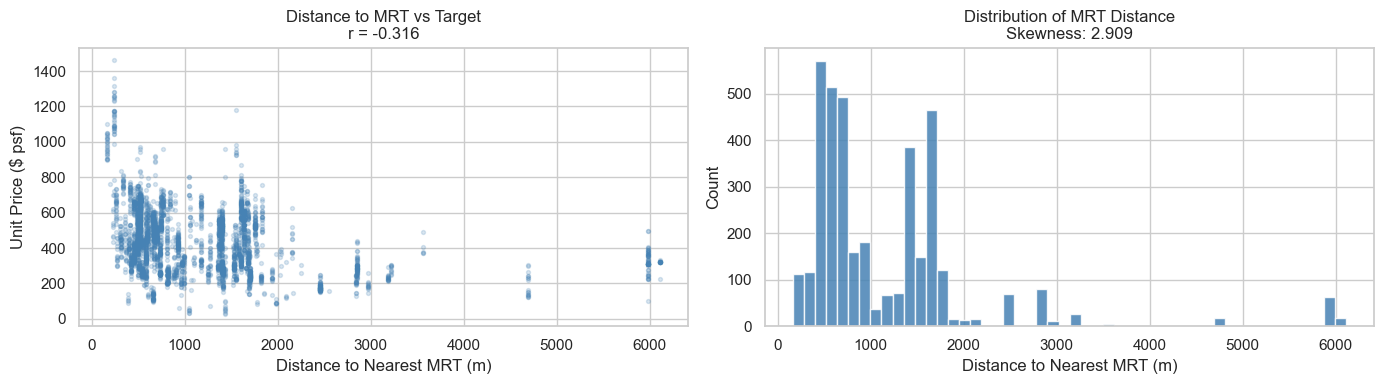

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# Merge to check correlation with target
df_check = df.merge(mrt_dist_df[["Project Name", "dist_to_mrt_m"]], on="Project Name", how="left")

r = df_check["dist_to_mrt_m"].corr(df_check["Unit Price ($ psf)"])
print(f"Correlation with Unit Price ($ psf): r = {r:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df_check["dist_to_mrt_m"], df_check["Unit Price ($ psf)"],
                alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("Distance to Nearest MRT (m)")
axes[0].set_ylabel("Unit Price ($ psf)")
axes[0].set_title(f"Distance to MRT vs Target\nr = {r:.3f}")

axes[1].hist(df_check["dist_to_mrt_m"].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Distance to Nearest MRT (m)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Distribution of MRT Distance\nSkewness: {df_check['dist_to_mrt_m'].skew():.3f}")

plt.tight_layout()
plt.show()

## 5. Merge & Save Updated Dataset

In [5]:
# Merge dist_to_mrt_m into factory_engineered
df_updated = df.merge(mrt_dist_df[["Project Name", "dist_to_mrt_m"]], on="Project Name", how="left")

# Check merge quality
missing = df_updated["dist_to_mrt_m"].isna().sum()
print(f"Rows with dist_to_mrt_m:         {df_updated['dist_to_mrt_m'].notna().sum()} / {len(df_updated)}")
print(f"Rows missing dist_to_mrt_m:      {missing} (rows with failed geocoding)")

# Fill missing with median — for rows where geocoding failed
if missing > 0:
    median_dist = df_updated["dist_to_mrt_m"].median()
    df_updated["dist_to_mrt_m"] = df_updated["dist_to_mrt_m"].fillna(median_dist)
    print(f"Filled {missing} missing values with median: {median_dist:.1f}m")

# Save updated dataset
df_updated.to_csv("../data/processed/factory_engineered.csv", index=False)

# Save geocoded building lookup for reference
mrt_dist_df.to_csv("../data/processed/property_geocoded.csv", index=False)

print(f"\nSaved:")
print(f"  data/processed/factory_engineered.csv  (updated with dist_to_mrt_m)")
print(f"  data/processed/property_geocoded.csv   (building geocodes + MRT distances)")
print(f"\nNew shape: {df_updated.shape}")
print(f"\nCorrelation with target: r = {df_updated['dist_to_mrt_m'].corr(df_updated['Unit Price ($ psf)']):.3f}")

Rows with dist_to_mrt_m:         3782 / 3782
Rows missing dist_to_mrt_m:      0 (rows with failed geocoding)

Saved:
  data/processed/factory_engineered.csv  (updated with dist_to_mrt_m)
  data/processed/property_geocoded.csv   (building geocodes + MRT distances)

New shape: (3782, 22)

Correlation with target: r = -0.316
